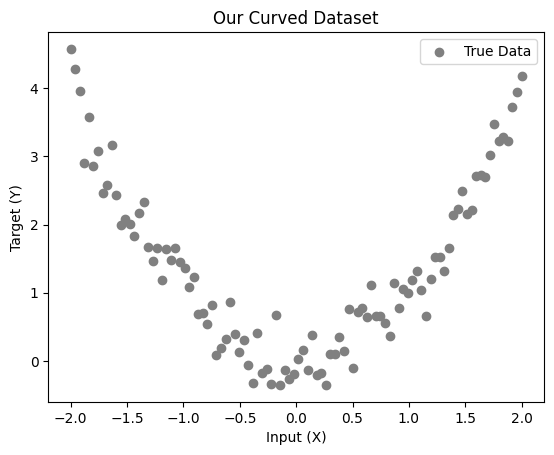

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 1. Generate synthetic curved data
torch.manual_seed(42)
X = torch.linspace(-2, 2, 100).unsqueeze(1) # 100 points between -2 and 2
Y = X**2 + torch.randn(X.size()) * 0.3       # y = x^2 + random noise

# Plot the raw dataset
plt.scatter(X.numpy(), Y.numpy(), color='gray', label='True Data')
plt.title("Our Curved Dataset")
plt.xlabel("Input (X)")
plt.ylabel("Target (Y)")
plt.legend()
plt.show()

In [2]:
# Define Linear Regression
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1) # 1 input, 1 output (y = wx + b)

    def forward(self, x):
        return self.linear(x)

# Initialize model, loss function (Mean Squared Error), and optimizer
lin_model = LinearRegressionModel()
criterion = nn.MSELoss()
optimizer = optim.SGD(lin_model.parameters(), lr=0.05)

# Training Loop
for epoch in range(200):
    predictions = lin_model(X)       # 1. Forward pass (calculate line)
    loss = criterion(predictions, Y) # 2. Calculate residual/error

    optimizer.zero_grad()            # 3. Clear old gradients
    loss.backward()                  # 4. Backpropagation (find parameter adjustments)
    optimizer.step()                 # 5. Tweak weights and bias

# Get final predictions
lin_predictions = lin_model(X).detach().numpy()

In [3]:
# Define Neural Network
class NeuralNetworkModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(1, 10),  # Hidden Layer: maps 1 input to 10 linear equations
            nn.ReLU(),         # Activation Function: Bends the 10 equations non-linearly
            nn.Linear(10, 1)   # Output Layer: Combines them back to 1 final output
        )

    def forward(self, x):
        return self.network(x)

# Initialize model, loss, and optimizer
nn_model = NeuralNetworkModel()
criterion = nn.MSELoss()
optimizer = optim.Adam(nn_model.parameters(), lr=0.02) # Adam works better for networks

# Training Loop
for epoch in range(1000): # Networks take a bit longer to tune all parameters
    predictions = nn_model(X)
    loss = criterion(predictions, Y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# Get final predictions
nn_predictions = nn_model(X).detach().numpy()

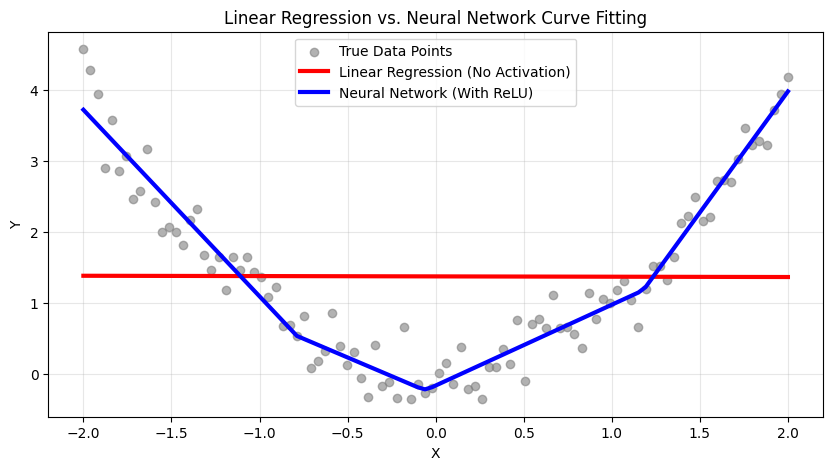

In [4]:
plt.figure(figsize=(10, 5))

# Plot original data points
plt.scatter(X.numpy(), Y.numpy(), color='gray', alpha=0.6, label='True Data Points')

# Plot Linear Regression line
plt.plot(X.numpy(), lin_predictions, color='red', linewidth=3, label='Linear Regression (No Activation)')

# Plot Neural Network curve
plt.plot(X.numpy(), nn_predictions, color='blue', linewidth=3, label='Neural Network (With ReLU)')

plt.title("Linear Regression vs. Neural Network Curve Fitting")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()